Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
1982.0
42 43
[23.81120219 23.10465753 23.74876712 25.31369863 25.28551913]
[25.60410959 24.19890411 26.11202186 24.92931507 25.31232877]
0.5695919818634785
1000
[np.float64(0.017715225019077963), np.float64(0.1106541705389894), np.float64(-0.32671902103400896), np.float64(-0.11778418778071043), np.float64(0.024365568871289156)]
-0.0060402081329816535
0.008


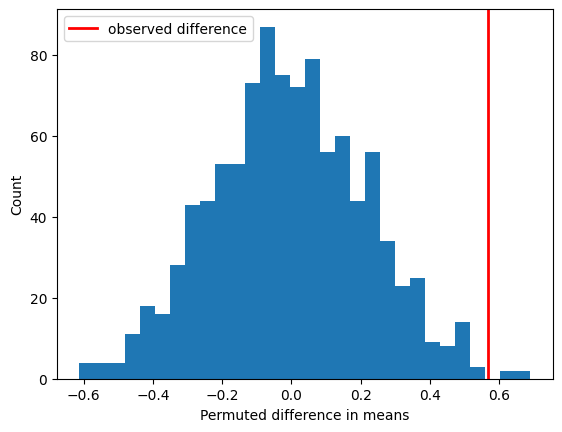

In [33]:
from posixpath import defpath
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('/content/drive/MyDrive/Data Science/Data/climate_austin.csv')

df.head()
len(df)





# Question: we check there is a year column
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year

df[['date', 'year']].head()

# Question: we are creating a value per year first
yearly = df.groupby('year')['temp_max'].mean().reset_index()
yearly.head()

# Question: we can recreate the Lesson 6 two-group split from the yearly data
midpoint = yearly['year'].median()
group1_df = yearly[yearly['year'] < midpoint]
group2_df = yearly[yearly['year'] >= midpoint]

print(midpoint)
print(len(group1_df), len(group2_df))

# Question: we are extracting the temperature values for each group so we can compare them
group1 = group1_df['temp_max'].values
group2 = group2_df['temp_max'].values

print(group1[:5])
print(group2[:5])

# Question: it is trying to find the difference of the means
observed_diff = group2.mean() - group1.mean()
print(observed_diff)

# Question: It will set up the group sizes, combine the data, choose how many permutations to run, and create an empty place to store the permuted differences.
n1 = len(group1)
n2 = len(group2)
combined = np.concatenate([group1, group2])
n_perm = 1000  # <- just changed
perm_diffs = []

# Question: 1. shuffles the combined temperatures 2. splits them back into two groups of the original sizes 3. computes the difference in mean temperature between those shuffled groups 4. stores that difference
for i in range(n_perm):
    shuffled = np.random.permutation(combined)
    new_group1 = shuffled[:n1]
    new_group2 = shuffled[n1:]
    perm_diff = new_group2.mean() - new_group1.mean()
    perm_diffs.append(perm_diff)

print(len(perm_diffs))
print(perm_diffs[:5])
print(np.mean(perm_diffs))


p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))
print(p_value)


fig, ax = plt.subplots()
ax.hist(perm_diffs, bins=30)  # <- just added
ax.axvline(observed_diff, color='red', linewidth=2, label='observed difference')
ax.set_xlabel('Permuted difference in means')
ax.set_ylabel('Count')
ax.legend()

H0: There is no real difference in true mean temperature between years before 1982 and years from 1982 onward; any observed difference is due to chance.
H1: There is a real difference in true mean temperature between years before 1982 and years from 1982 onward.

the default claim that there is no real difference in the true mean temperature between your two groups; any observed difference came from chance. between years before 1982 and years from 1982 onward
the claim that there is a real difference in the true mean temperature between your two groups. between years before 1982 and years from 1982 onward
+0.57°C (later years warmer)
if this were the only number in your report, I wouldn't knwo if this is actually very accurate and very usual.

- your observed difference: +0.57°C
- your p-value for n_perm = 1000
- your p-value for n_perm = 10000 = 0.0096
- whether the result is statistically significant at 0.05
- 1–2 sentences on whether this matched what you expected from Lesson 6

- rows: H0 is actually true / H0 is actually false
- columns: We reject H0 / We fail to reject H0

My null hypothesis was that there is no real difference in true mean temperature between years before 1982 and years from 1982 onward, and my alternative hypothesis was that there is a real difference. My observed difference in means was +0.57°C, and my permutation test p-value was 0.0096, which is less than 0.05, so I reject H0 and conclude that the difference is statistically significant. If this conclusion is wrong, it would be a Type I error: claiming a real difference between the two periods when in truth there is not one.